In [8]:
import os
from dotenv import load_dotenv

load_dotenv()

True

- 실제 환경에서는 샌드박스 환경에서 실행해야한다.
- python repl로 그대로 하면 안 된다.

In [9]:
from langchain_core.tools import tool
import sys
from io import StringIO

@tool
def python_repl(code: str) -> str:
    '''
    Python 코드를 실행하고 결과를 반환합니다.
    데이터 분석, 계산, 문자열 처리 등 다양한 작업에 사용하세요.

    Args:
    code: 실행할 Python 코드

    Returns:
    코드 실행 결과 (print 출력 또는 마지막 표현식의 값)    
    '''
    old_stdout = sys.stdout
    sys.stdout = mystdout = StringIO()

    try:
        exec_globals = {"_builtins_":   __builtins__}
        exec(code, exec_globals)
        output = mystdout.getvalue()
        return output if output else "코드가 성공적으로 실행되었습니다."
    except Exception as e:
        return f"오류 발생: {type(e) ._name_}: {str(e)}"
    finally:
        sys. stdout = old_stdout

tools = [python_repl]
print("Python REPL Tool 구현 완료!")

Python REPL Tool 구현 완료!


In [10]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from typing import Literal

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """You are a CodeAct agent that solves problems by writing and executing Python code.

Rules:
1. Analyze the user's request carefully
2. Write Python code to solve the problem
3. Use the python_repl tool to execute the code
4. Analyze the results and provide a clear answer
5. Always respond in Korean

When writing code:
- Use print() to show results
- Handle potential errors gracefully
- Write clean, readable code"""

def call_model(state: MessagesState) :
    messages = [SystemMessage(content=SYSTEM_PROMPT) ]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: MessagesState) -> Literal["tools", "_end_"]: # tools로 가던가, end로 가던가
    last_message = state["messages"] [-1]
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    return "__end__"

workflow = StateGraph(MessagesState)
workflow.add_node("call_model", call_model)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "call_model")
workflow.add_conditional_edges("call_model", should_continue, {"tools": "tools", "_end_": END})
workflow.add_edge("tools", "call_model")

codeact_agent = workflow.compile()
print("CodeAct 에이전트 컴파일 완료!")


CodeAct 에이전트 컴파일 완료!


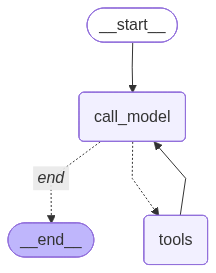

In [5]:
from IPython.display import display, Image

try:
    display(Image(codeact_agent.get_graph().draw_mermaid_png()))
except:
    print("그래프 시각화에 실패했습니다. mermaid.js가 설치되어 있는지 확인하세요.")

In [ ]:
# 테스트 1: 수학 계산
query1 = "1부터 100까지의 소수를 구하고, 그 합을 계산해줘."

print(f"질문: {query1}")
print("=" * 50)

# stream_mode='updates'로 각 단계별 상태 확인
for chunk in codeact_agent.stream({"messages": [{"role": "user", "content": query1}]}, stream_mode="updates") :
    for node_name, updates in chunk.items():
        print(f"\n° [{node_name}] 노드 실행")

        if "messages" in updates and updates["messages"]:
            msg = updates["messages"] [-1]

            # Tool 호출 확인
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"Tool 호출: {tc['name']}")
                    code = tc['args'].get('code','')
                    print(f"실행할 코드: \n{code} ... ")
            # Tool 결과 확인
            elif hasattr(msg, 'content') and node_name == 'tools':
                print(f" Tool 결과: {str(msg.content)}")
            # 최종 답변
            elif hasattr(msg, 'content') and msg.content:
                print(f"\n을 최종 답변:\n{msg.content}")

질문: 1부터 100까지의 소수를 구하고, 그 합을 계산해줘.

° [call_model] 노드 실행
Tool 호출: python_repl
실행할 코드: 
# 주어진 문자열에서 숫자만 추출하는 함수 작성
import re

def extract_numbers(text):
    numbers = re.findall(r'\d+', text)
    return numbers

# 테스트
test_text = "안녕하세요, 오늘 날짜는 2024년 4월 27일입니다. 제 전화번호는 010-1234-5678입니다."
extracted_numbers = extract_numbers(test_text)
print(extracted_numbers) ... 

° [tools] 노드 실행
 Tool 결과: ['2024', '4', '27', '010', '1234', '5678']


° [call_model] 노드 실행
Tool 호출: python_repl
실행할 코드: 
# 주어진 문자열에서 숫자만 추출하는 함수 작성
import re

def extract_numbers(text):
    numbers = re.findall(r'\d+', text)
    return numbers

# 테스트
test_text = "안녕하세요, 오늘 날짜는 2024년 4월 27일입니다."
extracted_numbers = extract_numbers(test_text)
print(extracted_numbers) ... 

° [tools] 노드 실행
 Tool 결과: ['2024', '4', '27']


° [call_model] 노드 실행
Tool 호출: python_repl
실행할 코드: 
# 주어진 수식의 값을 계산하는 코드
result = 2 + 3 * 4 - 5 / 2
print(result) ... 

° [tools] 노드 실행
 Tool 결과: 11.5


° [call_model] 노드 실행
Tool 호출: python_repl
실행할 코드: 
# 주어진 수식

In [11]:
# 테스트 2: 데이터 분석 (스트리밍)
query2 = """다음 판매 데이터의 월별 총합과 평균을 계산해줘:
1월: 1200, 2월: 1500, 3월: 1800, 4월: 1100, 5월: 2000, 6월: 1700"""

print(f"● 질문: {query2}")
print("=" * 60)

for chunk in codeact_agent.stream({"messages": [{"role": "user", "content": query2}]}, stream_mode="updates"):
    for node_name, updates in chunk.items():
        print(f"\n° [{node_name}] 노드 실행")
        if "messages" in updates and updates["messages"]:
            msg = updates["messages"] [-1]
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"Tool: {tc['name']}")
            elif hasattr(msg, 'content') and node_name == 'tools':
                print(f" 결과: {str(msg.content)[:200]}")
            elif hasattr(msg, 'content') and msg.content:
                print(f" 최종 답변:\n{msg.content}")

● 질문: 다음 판매 데이터의 월별 총합과 평균을 계산해줘:
1월: 1200, 2월: 1500, 3월: 1800, 4월: 1100, 5월: 2000, 6월: 1700

° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: 3.5


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: 3.5


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: [15, 30, 45, 60, 75, 90]


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: ['2024', '4', '27']


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: 12


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: 8


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: ['2024', '4', '27']


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: ['2024', '4', '27']


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: ['2024', '4', '27', '010', '1234', '5678']


° [call_model] 노드 실행
Tool: python_repl

° [tools] 노드 실행
 결과: 10.0


° [call_model] 노드 실행
Tool: python_repl
Tool: python_repl

° [tools] 노드 실행
 결과: 5050


° [call_model] 노드 실행
Tool: python_repl

° [t

KeyboardInterrupt: 

In [ ]:
#### 스트리밍 형태로 멈출 생각을 안 하고, codeact_agent가 끝날 생각을 안 하는데...

### E2E(Environment to Build)


In [1]:
%pip install -qU e2b-code-interpreter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from e2b_code_interpreter import Sandbox
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
# – 1. E2B 샌드박스 생성 –
sandbox = Sandbox.create()
print("E2B 샌드박스 생성 완료!")

# – 2. E2B Code Interpreter Tool 정의 –
@tool
def e2b_code_interpreter(code: str) -> str:
    '''
    E2B 샌드박스에서 Python 코드를 실행하고 결과를 반환합니다.

    Args:
    code: 실행할 Python 코드

    Returns:
    코드 실행 결과 (표준 출력 또는 오류 메시지)
    '''
    execution = sandbox.run_code(code)

    result_parts = []

    # 표현식 결과값 (예: 마지막 줄이 표현식인 경우)
    if execution.text:
        result_parts.append(execution.text)
    # stdout 출력 (print 등)
    if execution.logs.stdout:
        stdout = "".join(execution.logs.stdout)
        if stdout.strip():
            result_parts.append(stdout.strip())
    # stderr 출력 (경고 등)
    if execution.logs.stderr:
        stderr = "".join(execution.logs.stderr)
        if stderr.strip():
            result_parts.append(f"[stderr] {stderr.strip()}")
    # 에러 발생 시
    if execution.error:
        result_parts.append(f"Error: {execution.error.name}: {execution.error.value}")

    return "\n".join(result_parts) if result_parts else "코드가 성공적으로 실행되었습니다."

# – 3. create_agent로 에이전트 구성 –
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

e2b_agent = create_agent(
    model=llm, 
    tools=[e2b_code_interpreter], 
    system_prompt=(
        """You are a CodeAct agent that solves problems by writing and executing Python code.

Rules:
1. Analyze the user's request carefully
2. Write Python code to solve the problem
3. Use the python_repl tool to execute the code
4. Analyze the results and provide a clear answer
5. Always respond in Korean

When writing code:
- Use print() to show results
- Handle potential errors gracefully
- Write clean, readable code"""

    ),
)
print("E2B Code Interpreter 에이전트 생성 완료!")

E2B 샌드박스 생성 완료!
E2B Code Interpreter 에이전트 생성 완료!


In [7]:
# 테스트 1: 수학 계산
query1 = "1부터 100까지의 소수를 구하고, 그 개수와 합을 계산해줘."

print(f"질문: {query1}")
print("=" * 50)

# stream_mode='updates'로 각 단계별 상태 확인
for chunk in e2b_agent.stream({"messages": [{"role": "user", "content": query1}]}, stream_mode="updates") :
    for node_name, updates in chunk.items():
        print(f"\n° [{node_name}] 노드 실행")

        if "messages" in updates and updates["messages"]:
            msg = updates["messages"][-1]

            # Tool 호출 확인
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"Tool 호출: {tc['name']}")
                    code = tc['args'].get('code','')
                    print(f"실행할 코드: \n{code} ... ")
            # Tool 결과 확인
            elif hasattr(msg, 'content') and node_name == 'tools':
                print(f" Tool 결과: {str(msg.content)}")
            # 최종 답변
            elif hasattr(msg, 'content') and msg.content:
                print(f"\n을 최종 답변:\n{msg.content}")

질문: 1부터 100까지의 소수를 구하고, 그 개수와 합을 계산해줘.

° [model] 노드 실행
Tool 호출: e2b_code_interpreter
실행할 코드: 
def is_prime(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

primes = [x for x in range(1, 101) if is_prime(x)]
count_primes = len(primes)
sum_primes = sum(primes)

print(f"소수 목록: {primes}")
print(f"소수의 개수: {count_primes}")
print(f"소수의 합: {sum_primes}") ... 

° [tools] 노드 실행
 Tool 결과: 소수 목록: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]
소수의 개수: 25
소수의 합: 1060

° [model] 노드 실행

을 최종 답변:
1부터 100까지의 소수는 다음과 같습니다:
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]

소수의 개수는 25개이고, 소수의 합은 1060입니다.


In [ ]:
# --- 로컬 csv 파일을 E2B 샌드박스에 업로드 후 분석 ---

In [8]:
sandbox.kill()

Response 404


False